# The Burning Cost Analysis

## 1. Actuarial Theory: First Principles of Burning Cost

In insurance pricing, the Burning Cost (BC) (often synonymous with Pure Premium or Risk Premium) represents the expected cost of claims per unit of exposure before the addition of expenses, profit margins, and risk loads. It is the fundamental building block of any premium.

From first principles, the Burning Cost is driven by two underlying stochastic processes:

1. **Claim Frequency ($F$)**: The expected number of claims per unit of exposure.

2. **Claim Severity ($S$):** The expected cost per claim.

Mathematically, if $N$ is the random variable for the number of claims, $X_i$ is the severity of the $i$-th claim, and $E$ is the exposure (e.g., member-months or policy-years), the total aggregate loss $L$ is:

$$L = \sum_{i=1}^{N} X_i$$

Assuming frequency and severity are independent, the expected aggregate loss $\mathbb{E}[L]$ is:

$$\mathbb{E}[L] = \mathbb{E}[N] \cdot \mathbb{E}[X]$$

The historical Burning Cost (Pure Premium) is therefore:

$$BC = \frac{\mathbb{E}[L]}{E} = \left( \frac{\mathbb{E}[N]}{E} \right) \cdot \mathbb{E}[X] = F \cdot S$$

### The Trend Adjustment

Historical burning costs cannot be used directly to price future periods. In health insurance, medical inflation (trend) heavily distorts historical severities, while utilization trends distort frequencies. To calculate the projected burning cost for a future rating period, we must "trend" the historical data.

If the annual medical trend rate is $r$ and we are projecting $t$ years from the midpoint of the experience period to the midpoint of the rating period:

$$BC_{projected} = BC_{historical} \times (1 + r)^t$$

***Reference: Parodi, P. (2014). Pricing in General Insurance. Chapman and Hall/CRC.***

## 2. Real-World Application: Corporate Medical Schemes in Kenya

**The Business Problem:**

In the Kenyan InsurTech and traditional insurance landscape (e.g., Jubilee, Britam, or startups managing SHIF/NHIF supplements), pricing corporate health schemes is highly competitive. Medical inflation in Kenya historically hovers around 10% to 15%, significantly outpacing general inflation due to the rising costs of imported pharmaceuticals and private healthcare provider fees.

**The Solution:**

Actuaries use Burning Cost Analysis on a client's historical claims experience (usually 3 to 5 years) to price next year's policy. By isolating exposures (number of employees + dependents), analyzing historical frequency/severity, and applying a medical trend vector, insurers can calculate the exact base premium required to cover next year's expected healthcare utilization without making a loss.

## 3. Example Parameters for Implementation

We will model a mid-sized Kenyan technology company's medical scheme over the last 3 years. We are currently at the end of Year 3, pricing for Year 4.

- **Year 1:** 1,000 members, 2,500 claims, Total Claims: KES 20,000,000

- **Year 2:** 1,100 members, 2,860 claims, Total Claims: KES 25,740,000

- **Year 3:** 1,200 members, 3,360 claims, Total Claims: KES 34,272,000

- **Medical Trend:** 12% per annum ($r = 0.12$)

- **Projection:** From the midpoint of each historical year to the midpoint of Year 4.

## 4. Python Implementation

In [8]:

# Cell 1: Actuarial Pricing Build-Up for Health Insurance in Kenya
# imports 
import numpy as np
import pandas as pd 


# 1. Setup Data: Historical Claims Experience
# In real live scenarios, you would load this data from a file or database. For this example, we will create a synthetic dataset.
# Columns representing 3 consecutive historical years. 

years = np.array([1, 2, 3])
exposures = np.array([1000, 1100, 1200])  # Number of members
claim_counts = np.array([2500, 2860, 3360]) # Number of claims
total_losses = np.array([20_000_000, 25_740_000, 34_272_000]) # In KES

# Pricing Parameters
target_pricing_year = 4
medical_trend_pa = 0.12 # 12% annual medical inflation


# 2. Calculate First Principles: Frequency and Severity
frequencies = claim_counts / exposures
severities = total_losses / claim_counts

# 3. Calculate Historical Burning Cost (Pure Premium)
# BX= Frequency x Severity (Which mathematically equates to Total Losses / Exposures)
historical_bcs = frequencies * severities

# 4. Apply Medical Trend to Project to the Target Pricing Year
# We project from the midpoint of the historical year to the midpoint of the target pricing year. 
trend_periods = target_pricing_year - years 
trend_factors = (1 + medical_trend_pa) ** trend_periods

projected_bcs = historical_bcs * trend_factors


# 5. Calculate Blended Target Burning Cost 
# We weight the projected burning costs by historical exposure
# (giving more credibility to years with larger membership pools)
weights = exposures / np.sum(exposures)
final_blended_bc = np.sum(projected_bcs * weights)

# 6. Display the Step-by-Step Actuarial Build-Up 
print("--- Actuarial Pricing Build-Up ---")
for i in range(len(years)):
    print(f"Year {years[i]}:")
    print(f" Frequency: {frequencies[i]:.2f} | Severities: KES {severities[i]:,.0f}")
    print(f" Historical BC: KES {historical_bcs[i]:,.0f}")
    print(f" Trend Factor : {trend_factors[i]:.4f} ({trend_periods[i]}) years @ {medical_trend_pa*100}%)")
    print(f" Projected BC : ")
    print(f" Weight       : {weights[i]*100:.1f}%\n")

print("-" * 34)
print(f"Final Blended Target BC (Year {target_pricing_year}): KES {final_blended_bc:,.2f} per member")

--- Actuarial Pricing Build-Up ---
Year 1:
 Frequency: 2.50 | Severities: KES 8,000
 Historical BC: KES 20,000
 Trend Factor : 1.4049 (3) years @ 12.0%)
 Projected BC : 
 Weight       : 30.3%

Year 2:
 Frequency: 2.60 | Severities: KES 9,000
 Historical BC: KES 23,400
 Trend Factor : 1.2544 (2) years @ 12.0%)
 Projected BC : 
 Weight       : 33.3%

Year 3:
 Frequency: 2.80 | Severities: KES 10,200
 Historical BC: KES 28,560
 Trend Factor : 1.1200 (1) years @ 12.0%)
 Projected BC : 
 Weight       : 36.4%

----------------------------------
Final Blended Target BC (Year 4): KES 29,930.74 per member


### Visualization - Historical vs. Trended Costs

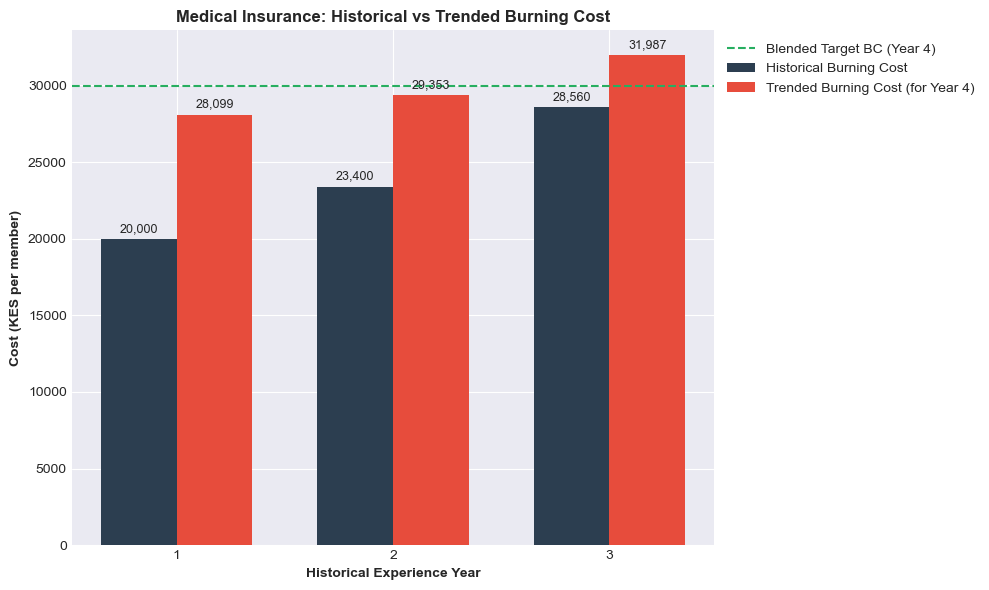

In [10]:
# Cell 2: Visualization of Burning Cost Development
import matplotlib.pyplot as plt

def plot_step_by_step(years, historical_bc, proj_bc, final_bc, target_year):
    """
    Visualizes the gap between historical experience and trend projections using flat arrays.
    """

    # Use the professional styling we set up earlier 
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, ax = plt.subplots(figsize=(10, 6))

    width = 0.35

    # Plotting Historical vs Projected using arrays
    ax.bar(years - width/ 2, historical_bc, width, label="Historical Burning Cost", color="#2c3e50")
    ax.bar(years + width/ 2, proj_bc, width, label=f"Trended Burning Cost (for Year {target_year})", color="#e74c3c")
    
    # Add a horizontal line for the final weighted premium 
    ax.axhline(final_bc, color="#27ae60", linestyle="--", label=f"Blended Target BC (Year {target_year})")
    ax.set_xlabel("Historical Experience Year", fontweight="bold")
    ax.set_ylabel("Cost (KES per member)", fontweight="bold")
    ax.set_title("Medical Insurance: Historical vs Trended Burning Cost", fontweight="bold")
    ax.set_xticks(years)

    # Place the legend outside or optimally so it doesn't block the bars 
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))

    # Annotate values using standard index iteration instead of iterrows()
    for i in range(len(years)):
        ax.annotate(f"{historical_bc[i]:,.0f}", (years[i] - width/ 2, historical_bc[i]),
                    textcoords="offset points", xytext=(0, 5), ha='center', fontsize=9)
        ax.annotate(f"{proj_bc[i]:,.0f}", (years[i] + width/ 2, proj_bc[i]),
                    textcoords="offset points", xytext=(0, 5), ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()


# Call the function using numpy arrays generated in cell 1
plot_step_by_step(years, historical_bcs, projected_bcs, final_blended_bc, target_pricing_year)

## Reference

[***Parodi, P. (2014). Pricing in General Insurance. Chapman and Hall/CR***](../../books/Pricing-in-general-insurance.-Parodi-P.-Chapman-HallCRC-Press-2014.-ISBN-9781466581449.pdf)